## Prediction of Customer Churn Pbobability

The notebook in fourth entry to competition I started with Basics to start with, before I test pipelione and ensemble

**Version 2.0**
Random Forests tend to struggle with this because they average predictions from many trees, which often pushes probabilities away from 0 and 1 toward the center.
This version introduces Random Forest Calibration By applying Platt Scaling (Sigmoid calibration), turns a mathematical output into a reliable financial metric for churn prevention strategies.

**Version 3.0**
Introduced GridSearchCV: It no longer guesses the number of trees; it tests 50, 100, 150, 200, 250 and 300 to find the most accurate estimator for specific data.

In [1]:
# =============================================================================
# 1. Import Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, classification_report, brier_score_loss

# Set visual style
sns.set(style="whitegrid")


In [2]:
# =============================================================================
# 2. Data Loading 
# =============================================================================
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

print("Completed Loading Data ...")

# Descriptive Statistics
stats = train_df.describe()

print("\nDescriptive Stats:\n", stats)


Completed Loading Data ...

Descriptive Stats:
                   id  SeniorCitizen         tenure  MonthlyCharges  \
count  594194.000000  594194.000000  594194.000000   594194.000000   
mean   297096.500000       0.114102      36.577258       65.866223   
std    171529.177262       0.317936      25.061922       31.067444   
min         0.000000       0.000000       1.000000       18.250000   
25%    148548.250000       0.000000      12.000000       29.900000   
50%    297096.500000       0.000000      35.000000       74.100000   
75%    445644.750000       0.000000      62.000000       90.800000   
max    594193.000000       1.000000      72.000000      118.750000   

        TotalCharges  
count  594194.000000  
mean     2494.377057  
std      2353.916710  
min        18.800000  
25%       639.650000  
50%      1433.650000  
75%      4263.800000  
max      8684.800000  


/tmp/ipykernel_17/1690813596.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette='viridis', legend=False)


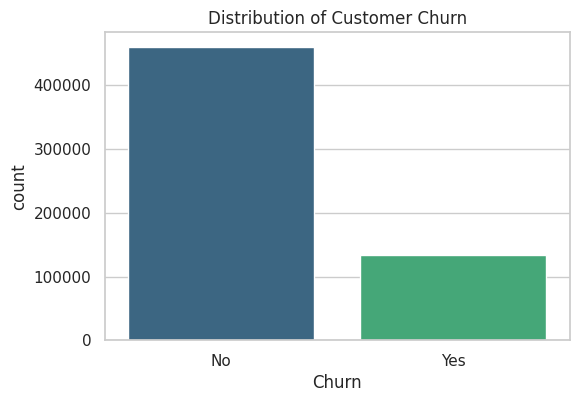

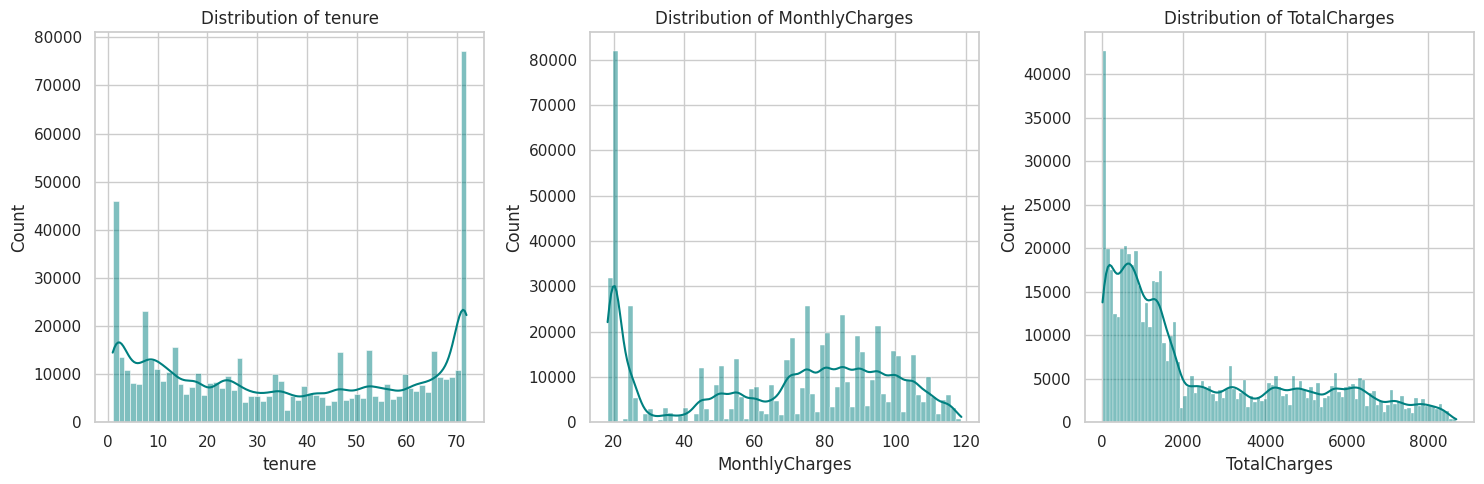

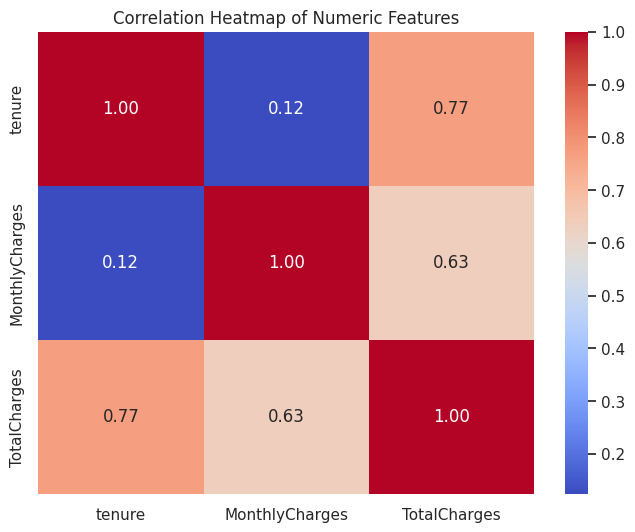

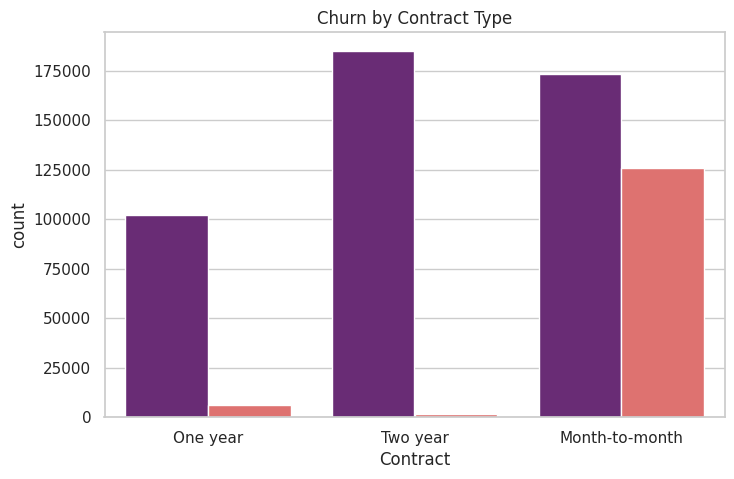

In [3]:
# =============================================================================
# 3. Basic Exploratory Data Analytics
# =============================================================================

# Clean TotalCharges for analysis
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(train_df['TotalCharges'].median())

# Distribution of Target Variable (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train_df, palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.savefig('churn_distribution.png')

# Numeric Features Distribution
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(train_df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numeric_distributions.png')

# Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation = train_df[numeric_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('correlation_heatmap.png')

# Churn by Contract Type (Categorical Analysis)
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=train_df, palette='magma', legend=False)
plt.title('Churn by Contract Type')
plt.savefig('churn_by_contract.png')


In [4]:
# =============================================================================
# 4. Label Encoding for Categorical Columns
# =============================================================================
le = LabelEncoder()
cat_features = train_df.select_dtypes(include=['object']).columns.drop(['Churn'])

for col in cat_features:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})

X = train_df.drop(['id', 'Churn'], axis=1)
y = train_df['Churn']
X_test_final = test_df.drop(['id'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# =============================================================================
# 5. Hyper Parameter Optimization
# =============================================================================
print("Optimizing n_estimators via Grid Search...")
param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300]}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(rf, param_grid, cv=6, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Best n_estimators: {grid_search.best_params_['n_estimators']}")

# Calibrating Model Probabilikties

print("Calibrating model probabilities...")
calibrated_rf = CalibratedClassifierCV(best_rf, method='sigmoid', cv=5)
calibrated_rf.fit(X_train, y_train)

Optimizing n_estimators via Grid Search...
Best n_estimators: 250
Calibrating model probabilities...


CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(n_estimators=250,
                                                        n_jobs=-1,
                                                        random_state=42))


Validation Accuracy: 0.8487
Brier Score: 0.1055


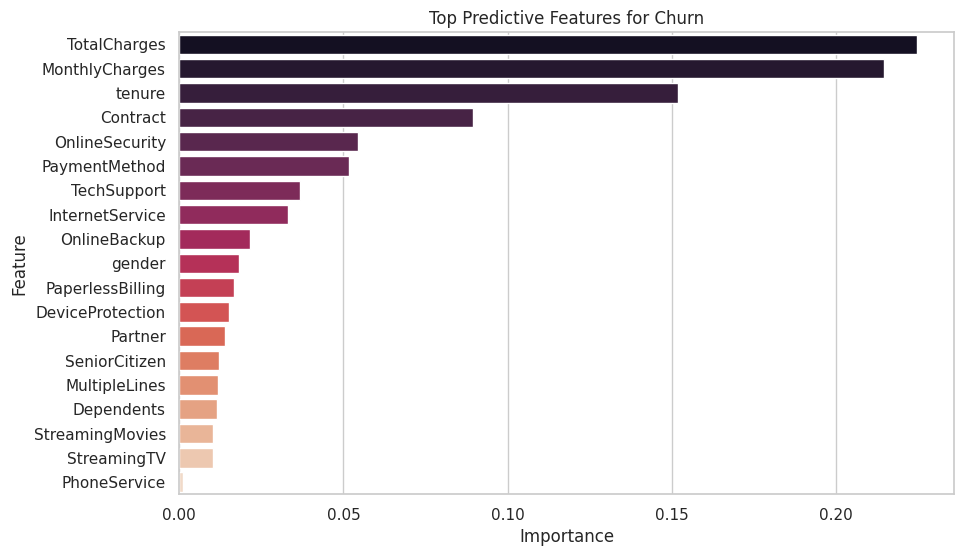

In [6]:
# =============================================================================
# 6. FEATURE IMPORTANCE VISUALIZATION
# =============================================================================
val_probs = calibrated_rf.predict_proba(X_val)[:, 1]
val_preds = calibrated_rf.predict(X_val)

print(f"\nValidation Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(f"Brier Score: {brier_score_loss(y_val, val_probs):.4f}")

# Feature Importance (from the internal estimator)
importances = calibrated_rf.calibrated_classifiers_[0].estimator.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, hue='Feature', palette='rocket', legend=False)
plt.title('Top Predictive Features for Churn')
plt.show()


In [7]:
# =============================================================================
# 7. Final Predictions
# =============================================================================
test_probs = calibrated_rf.predict_proba(X_test_final)[:, 1]
test_classes = calibrated_rf.predict(X_test_final)

TARGET = 'Churn'

# Create output dataframe
submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn_Probability': np.round(test_probs, 4)
})



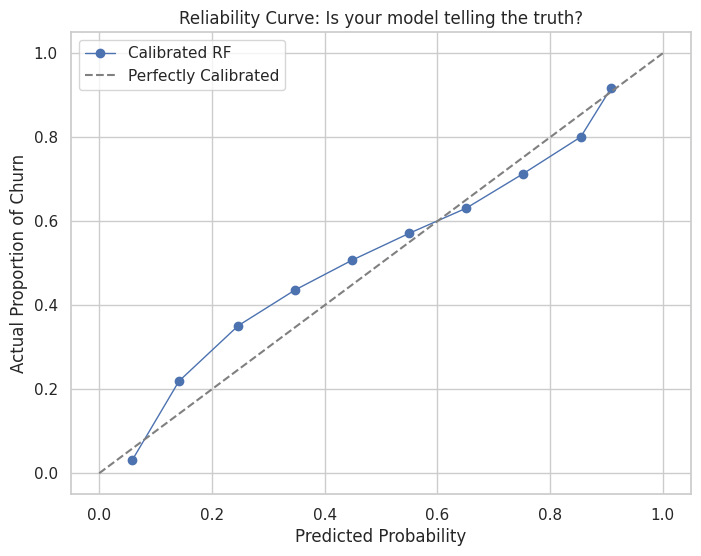

In [8]:
# =============================================================================
# 8. Calculate calibration curves - Measuring Reliability
# =============================================================================
prob_true, prob_pred = calibration_curve(y_val, calibrated_rf.predict_proba(X_val)[:, 1], n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibrated RF')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Predicted Probability')
plt.ylabel('Actual Proportion of Churn')
plt.title('Reliability Curve: Is your model telling the truth?')
plt.legend()
plt.show()

In [9]:
# =============================================================================
# 9. Submission
# =============================================================================
submission.to_csv("submission.csv", index=False)

print("\nSubmission Created Successfully.")

submission.head(20)



Submission Created Successfully.


,id,Churn_Probability
0,594194,0.0604
1,594195,0.0516
2,594196,0.0661
3,594197,0.0516
4,594198,0.2899
5,594199,0.1227
6,594200,0.8978
7,594201,0.0523
8,594202,0.0551
9,594203,0.2382
